# Upgrading scalar mass balance calibration technique

The scalar mass balance calibration technique currently only calibrates one parameter at a time and calibrates to the reference average mass balance only. We will be aiming to improve the calibration through the use of the WGMS dataset as this contains interannual data which can provide more metrics and data to calibrate to.

In this notebook we will:
1. Add minimization for both mean and standard deviation.
2. Calibrate to minimize RMSD.
3. Calibrate to minimize the RMSD and recursively minimise the mean.

## Set Up

First install required packages to run this tutorial. 

We will be using level 4 data to allow for the dynamical spinup and the calibration capabilities.

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import os

import oggm
from oggm import cfg, utils, workflow, tasks, graphics
from oggm.sandbox.edu import run_constant_climate_with_bias
import xarray as xr
from oggm.core import massbalance
from oggm.core.massbalance import mb_calibration_from_scalar_mb, mb_calibration_from_geodetic_mb

In [2]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2025-11-26 11:11:26: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-11-26 11:11:26: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-11-26 11:11:26: oggm.cfg: Multiprocessing: using all available processors (N=22)
2025-11-26 11:11:26: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-11-26 11:11:26: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-11-26 11:11:26: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [3]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2025-11-26 11:11:29: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-26 11:11:29: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


# **Calibration:** Calibrating to minimize the RMSD with WGMS data sets

Here we will be calibrating to minimize the RMSD using the glaciers with WGMS datasets. The WGMS dataset has yearly mass balance observations, which can allow us to calculate the RMSD for the glaciers we are looking to calibrate.

We will firstly calibrate the initial calibration with scalar default method in the OGGM.

In [4]:
from oggm.core.massbalance import mb_calibration_from_scalar_mb
from oggm.core.massbalance import MonthlyTIModel

mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

scalar_df = mb_calibration_from_scalar_mb(gdir_hef,
                            ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
                            ref_mb_years=mbdf.index.tolist(),
                            ref_period=None,
                            overwrite_gdir=True,
                            mb_model_class=MonthlyTIModel,
                            calibrate_param1='prcp_fac',
                            calibrate_param2='melt_f',
                            calibrate_param3='temp_bias',
                            melt_f_min=1.5,
                            melt_f_max=17.0,
                            temp_bias_min=-15.0,
                            temp_bias_max=15.0,
                            prcp_fac_min=0.1,
                            prcp_fac_max=10.0,
                            write_to_gdir=True)

scalar_df


{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 0.9783635516648428,
 'temp_bias': 0,
 'reference_mb': -1122.75,
 'reference_mb_err': None,
 'reference_period': 'custom',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

So above we have just calibrated the precipitation factor, this is because the mass balance is reached with just calibrating the precipitation factor.

Since we are calibrating to the mean mass balance, we achieve the mean mass balance exactly.

<Axes: xlabel='YEAR'>

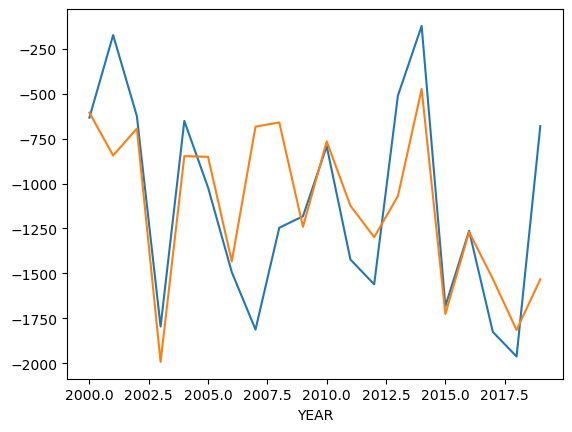

In [13]:
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
mbmod = massbalance.MonthlyTIModel(gdir_hef, # Running the simulation with the set parameters
                                           melt_f=scalar_df['melt_f'],
                                           prcp_fac=scalar_df['prcp_fac'],
                                           temp_bias=scalar_df['temp_bias'],
                                           check_calib_params=False) 
        

mbdf['mod_mb_0'] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=mbdf.index)

mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

mbdf['in_situ_mb'].plot()
mbdf['mod_mb_0'].plot()

# The results showing the calibration of prcp_fac with the rsmd minimization and then considering calibrating the last two parameters to match the mean MB

Let's quickly investigate the the rmsd in this calibration, this will help us understand if we are minimizing the rmsd that much in our new approach when calibrating to minimize the rmsd instead of minimizing the mean mass balance.

In [ ]:
from oggm.utils._funcs import rmsd

rmsd(mbdf['mod_mb_0'], mbdf['in_situ_mb']) # Here we can see the rmsd value for this calibration is large


425.6698678247701

# Calibration with the RMSD and the mean

Now we will update the scalar calibration technique to calibrate with the RMSD.

### Investigating how to calibrate with RMSD

To do this calibration we will be using the differential evolution method, this will calibrate all parameters at the same time and optimise to reduce the rmsd.

In [8]:
from oggm.core.massbalance import MonthlyTIModel, calving_mb, decide_winter_precip_factor
from oggm.exceptions import InvalidParamsError, InvalidWorkflowError
from oggm.utils._funcs import rmsd
from scipy import optimize
import xarray as xr

# Climate relevant global params - not optimised
MB_GLOBAL_PARAMS = ['temp_default_gradient',
                    'temp_all_solid',
                    'temp_all_liq',
                    'temp_melt']

# Using std and mean to calibrate here
def mb_calibration_from_wgms_mb(gdir, *,
                                  ref_mb=None,
                                  write_to_gdir=True,
                                  overwrite_gdir=False,
                                  use_2d_mb=False,
                                  calibrate_params=('melt_f',),
                                  melt_f=None,
                                  melt_f_min=None,
                                  melt_f_max=None,
                                  prcp_fac=None,
                                  prcp_fac_min=None,
                                  prcp_fac_max=None,
                                  temp_bias=None,
                                  temp_bias_min=None,
                                  temp_bias_max=None,
                                  mb_model_class=MonthlyTIModel,
                                  filesuffix='',
                                  ):
    """Determine the mass balance parameters from a scalar mass-balance value.

    This calibrates the mass balance parameters using a reference average
    MB data over a given period (e.g. average in-situ SMB or geodetic MB).
    This flexible calibration allows to calibrate three parameters one after
    another. The first parameter is varied between two chosen values (a range)
    until the ref MB value is matched. If this fails, the second parameter
    can be changed, etc.

    This can be used for example to apply the "three-step calibration"
    introduced by Huss & Hock 2015, but you can choose any order of
    calibration.

    This task can be called by other, "higher level" tasks, for example
    :py:func:`oggm.core.massbalance.mb_calibration_from_geodetic_mb` or
    :py:func:`oggm.core.massbalance.mb_calibration_from_wgms_mb`.

    Note that this does not compute the apparent mass balance at
    the same time - users need to run `apparent_mb_from_any_mb after`
    calibration.

    Parameters
    ----------
    gdir : :py:class:`oggm.GlacierDirectory`
        the glacier directory to calibrate
    ref_mb : float, required
        the reference mass balance to match (units: kg m-2 yr-1)
        It is required here - if you want to use available observations,
        use :py:func:`oggm.core.massbalance.mb_calibration_from_geodetic_mb`
        or :py:func:`oggm.core.massbalance.mb_calibration_from_wgms_mb`.
    ref_mb_err : float, optional
        currently only used for logging - it is not used in the calibration.
    ref_period : str, optional
        date format - for example '2000-01-01_2010-01-01'. If this is not
        set, ref_mb_years needs to be set.
    ref_mb_years : tuple of length 2 (range) or list of years.
        convenience kwarg to override ref_period. If a tuple of length 2 is
        given, all years between this range (excluding the last one) are used.
        If a list  of years is given, all these will be used (useful for
        data with gaps)
    write_to_gdir : bool
        whether to write the results of the calibration to the glacier
        directory. If True (the default), this will be saved as `mb_calib.json`
        and be used by the MassBalanceModel class as parameters in subsequent
        tasks.
    overwrite_gdir : bool
        if a `mb_calib.json` exists, this task won't overwrite it per default.
        Set this to True to enforce overwriting (i.e. with consequences for the
        future workflow).
    use_2d_mb : bool
        Set to True if the mass balance calibration has to be done of the 2D mask
        of the glacier (for fully distributed runs only).
    mb_model_class : MassBalanceModel class
        the MassBalanceModel to use for the calibration. Needs to use the
        same parameters as MonthlyTIModel (the default): melt_f,
        temp_bias, prcp_fac.
    calibrate_param1 : str
        in the three-step calibration, the name of the first parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac').
    calibrate_param2 : str
        in the three-step calibration, the name of the second parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac'). If not
        set and the algorithm cannot match observations, it will raise an
        error.
    calibrate_param3 : str
        in the three-step calibration, the name of the third parameter
        to calibrate (one of 'melt_f', 'temp_bias', 'prcp_fac'). If not
        set and the algorithm cannot match observations, it will raise an
        error.
    melt_f: float
        the default value to use as melt factor (or the starting value when
        optimizing MB). Defaults to cfg.PARAMS['melt_f'].
    melt_f_min: float
        the minimum accepted value for the melt factor during optimisation.
        Defaults to cfg.PARAMS['melt_f_min'].
    melt_f_max: float
        the maximum accepted value for the melt factor during optimisation.
        Defaults to cfg.PARAMS['melt_f_max'].
    prcp_fac: float
        the default value to use as precipitation scaling factor
        (or the starting value when optimizing MB). Defaults to the method
        chosen in `params.cfg` (winter prcp or global factor).
    prcp_fac_min: float
        the minimum accepted value for the precipitation scaling factor during
        optimisation. Defaults to cfg.PARAMS['prcp_fac_min'].
    prcp_fac_max: float
        the maximum accepted value for the precipitation scaling factor during
        optimisation. Defaults to cfg.PARAMS['prcp_fac_max'].
    temp_bias: float
        the default value to use as temperature bias (or the starting value when
        optimizing MB). Defaults to 0.
    temp_bias_min: float
        the minimum accepted value for the temperature bias during optimisation.
        Defaults to cfg.PARAMS['temp_bias_min'].
    temp_bias_max: float
        the maximum accepted value for the temperature bias during optimisation.
        Defaults to cfg.PARAMS['temp_bias_max'].
    filesuffix: str
        add a filesuffix to mb_calib.json. This could be useful for sensitivity
        analyses with MB models, if they need to fetch other sets of params for
        example.
    """

    # Param constraints
    if melt_f_min is None:
        melt_f_min = cfg.PARAMS['melt_f_min']
    if melt_f_max is None:
        melt_f_max = cfg.PARAMS['melt_f_max']
    if prcp_fac_min is None:
        prcp_fac_min = cfg.PARAMS['prcp_fac_min']
    if prcp_fac_max is None:
        prcp_fac_max = cfg.PARAMS['prcp_fac_max']
    if temp_bias_min is None:
        temp_bias_min = cfg.PARAMS['temp_bias_min']
    if temp_bias_max is None:
        temp_bias_max = cfg.PARAMS['temp_bias_max']

    if not use_2d_mb:
        fls = gdir.read_pickle('inversion_flowlines')
    else:
        # if the 2D data is used, the flowline is not needed.
        fls = None
        # get the 2D data
        fp = gdir.get_filepath('gridded_data')
        with xr.open_dataset(fp) as ds:
            # 'topo' instead of 'topo_smoothed'?
            heights = ds.topo_smoothed.data[ds.glacier_mask.data == 1]
            widths = np.ones(len(heights))

    # Climate period
    ref_mb_years = ref_mb.index.values
    years = ref_mb_years
    
    # Do we have a calving glacier?
    cmb = calving_mb(gdir)
    if cmb != 0:
        raise NotImplementedError('Calving with geodetic MB is not implemented '
                                  'yet, but it should actually work. Well keep '
                                  'you posted!')

    # Ok, regardless on how we want to calibrate, we start with defaults
    if melt_f is None:
        melt_f = cfg.PARAMS['melt_f']

    if prcp_fac is None:
        if cfg.PARAMS['use_winter_prcp_fac']:
            # Some sanity check
            if cfg.PARAMS['prcp_fac'] is not None:
                raise InvalidWorkflowError("Set PARAMS['prcp_fac'] to None "
                                           "if using PARAMS['winter_prcp_factor'].")
            prcp_fac = decide_winter_precip_factor(gdir)
        else:
            prcp_fac = cfg.PARAMS['prcp_fac']
            if prcp_fac is None:
                raise InvalidWorkflowError("Set either PARAMS['use_winter_prcp_fac'] "
                                           "or PARAMS['winter_prcp_factor'].")

    if temp_bias is None:
        temp_bias = 0

    # Create the MB model we will calibrate
    mb_mod = mb_model_class(gdir,
                            melt_f=melt_f,
                            temp_bias=temp_bias,
                            prcp_fac=prcp_fac,
                            check_calib_params=False)

    # Check that the years are available
    for y in years:
        if not mb_mod.is_year_valid(y):
            raise ValueError(f'year {y} out of the valid time bounds: '
                             f'[{mb_mod.ys}, {mb_mod.ye}]')

    # Check that the calibrate params are valid
    for param in calibrate_params:
        if param not in ('melt_f', 'prcp_fac', 'temp_bias'):
            raise InvalidParamsError("calibrate_params must be a tuple with any of "
                                     "'melt_f', 'prcp_fac', 'temp_bias'")
        
    # Set the bounds for the optimization
    bounds = []
    for param in calibrate_params:
        if param == 'prcp_fac':
            bounds.append((prcp_fac_min, prcp_fac_max))
        elif param == 'melt_f':
            bounds.append((melt_f_min, melt_f_max))
        elif param == 'temp_bias':
            bounds.append((temp_bias_min, temp_bias_max))
    
    # Firstly, fix the precipitation factor, prcp_fac and calibrate this to optimise the rmsd
    def rmsd_cost_function(x, *model_attrs: tuple):
        for i, model_attr in enumerate(model_attrs):
            setattr(mb_mod, model_attr, x[i])

        if use_2d_mb:
            sim_out = mb_mod.get_specific_mb(heights=heights, widths=widths, year=years)
        else:
            sim_out = mb_mod.get_specific_mb(fls=fls, year=years)

        return rmsd(ref_mb, sim_out)

    try:
        res = optimize.differential_evolution(rmsd_cost_function,
                                       bounds = bounds, # Use the default ranges set in the OGGM
                                       args=(calibrate_params), # Pass the parameters to calibrate
                                       )
        
        calib_params = res.x 

        # Assign parameters
        for i, param in enumerate(calibrate_params):
            if param == 'prcp_fac':
                prcp_fac = calib_params[i]
            elif param == 'melt_f':
                melt_f = calib_params[i]
            elif param == 'temp_bias':
                temp_bias = calib_params[i]

    # TODO: Change what happens if the minimization fails?? It probably now fails under new circumstances.
    except ValueError:
        raise RuntimeError(f'{gdir.rgi_id}: could not minimise the rmsd. '
                            f'Try another technique.')

    # Store parameters
    df = gdir.read_json('mb_calib', allow_empty=True)
    df['rgi_id'] = gdir.rgi_id
    df['bias'] = 0
    df['melt_f'] = melt_f
    df['prcp_fac'] = prcp_fac
    df['temp_bias'] = temp_bias
    # What did we try to match?
    df['reference_mb'] = ref_mb.values.mean()
    df['reference_period'] = str(ref_mb_years)
    df['rmsd'] = res.fun

    # Add the climate related params to the GlacierDir to make sure
    # other tools cannot fool around without re-calibration
    df['mb_global_params'] = {k: cfg.PARAMS[k] for k in MB_GLOBAL_PARAMS}
    df['baseline_climate_source'] = gdir.get_climate_info()['baseline_climate_source']
    # Write
    if write_to_gdir:
        if gdir.has_file('mb_calib', filesuffix=filesuffix) and not overwrite_gdir:
            raise InvalidWorkflowError('`mb_calib.json` already exists for '
                                       'this repository. Set `overwrite_gdir` '
                                       'to True if you want to overwrite '
                                       'a previous calibration.')
        gdir.write_json(df, 'mb_calib', filesuffix=filesuffix)
    return df

# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

df = mb_calibration_from_wgms_mb(gdir_hef,
                            ref_mb=mbdf['ANNUAL_BALANCE'],
                            overwrite_gdir=True,
                            mb_model_class=MonthlyTIModel,
                            calibrate_params= ('prcp_fac', 'melt_f', 'temp_bias'), # Changed to take in a tuple, this can allow us to change the order/number of parameters calibrated easily
                            melt_f_min=1.5,
                            melt_f_max=17.0,
                            temp_bias_min=-15.0,
                            temp_bias_max=15.0,
                            prcp_fac_min=0.1,
                            prcp_fac_max=10.0,
                            write_to_gdir=True)

df

2025-11-25 15:14:50: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-25 15:14:50: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 3.737605651302265,
 'prcp_fac': 2.2619012252693516,
 'temp_bias': 1.9243372356373316,
 'reference_mb': -1122.75,
 'reference_mb_err': 171.8,
 'reference_period': '[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013\n 2014 2015 2016 2017 2018 2019]',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5',
 'rmsd': 386.16932375054716}

We can see the parameters calibrated above, we can see that all of them have now been calibrated by the method rather than just one at a time.

We are attempting to minimize the rmsd here but we can see that the rmsd is still rather large. However, this is still smaller than the rmsd calculated previously.

Now plotting the results:

The simulated mass balance is -1118.5594186262176
The in-situ mass balance is -1122.75


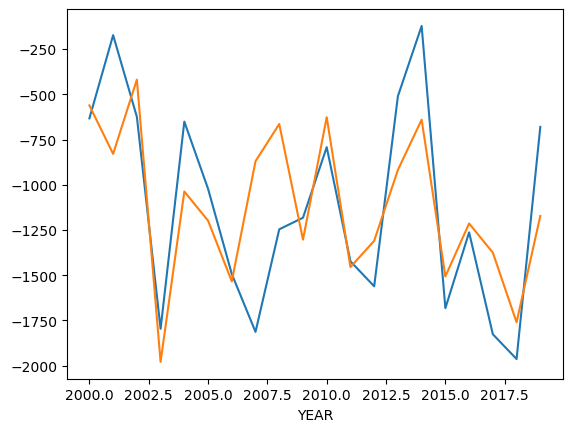

In [9]:
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
mbmod = massbalance.MonthlyTIModel(gdir_hef, # Running the simulation with the set parameters
                                           melt_f=df['melt_f'],
                                           prcp_fac=df['prcp_fac'],
                                           temp_bias=df['temp_bias'],
                                           check_calib_params=False) 
        

mbdf['mod_mb_0'] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=mbdf.index)

mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

mbdf['in_situ_mb'].plot()
mbdf['mod_mb_0'].plot()

print("The simulated mass balance is", mbdf['mod_mb_0'].mean())
print("The in-situ mass balance is", mbdf['in_situ_mb'].mean())

# The results showing the calibration of the three parameters with the rmsd minimization

Lets check the mean, std and rmsd to see what has been minimised and what the average errors are here against our observed data:

In [10]:
mbdf['mod_mb_0'].mean() - mbdf['in_situ_mb'].mean()

4.190581373782379

Now I will experiment with another glacier with WGMS data to see if this works again

In [10]:
from oggm.utils._downloads import get_wgms_files

clean_db = list(get_wgms_files())[0].drop([99])

wgms_data_list = list(clean_db['RGI60_ID'])

base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdirs = workflow.init_glacier_directories(wgms_data_list, from_prepro_level=5, prepro_border=160, prepro_base_url=base_url)

2025-11-21 16:10:53: oggm.workflow: init_glacier_directories from prepro level 5 on 289 glaciers.
2025-11-21 16:10:53: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 289 glaciers
2025-11-21 16:10:53: oggm.workflow: WARNING: you are trying to run an entity task on 289 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.


In [11]:
# First glacier in the list
rgi_id = gdirs[0].rgi_id

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_new = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2025-11-21 16:12:44: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-21 16:12:44: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [12]:
mbdf = gdir_new.get_ref_mb_data().loc[2000:2019] # WGMS data for new glacier

df = mb_calibration_from_wgms_mb(gdir_new,
                            ref_mb=mbdf['ANNUAL_BALANCE'],
                            overwrite_gdir=True,
                            mb_model_class=MonthlyTIModel,
                            calibrate_params= ('prcp_fac', 'melt_f', 'temp_bias'), # Changed to take in a tuple, this can allow us to change the order/number of parameters calibrated easily
                            melt_f_min=1.5,
                            melt_f_max=17.0,
                            temp_bias_min=-15.0,
                            temp_bias_max=15.0,
                            prcp_fac_min=0.1,
                            prcp_fac_max=10.0,
                            write_to_gdir=True,
                            )

df

2025-11-21 16:12:45: oggm.utils: You are trying to set MB data on a tidewater glacier! These data will be ignored by the MB model calibration routine.


{'rgi_id': 'RGI60-19.00595',
 'bias': 0,
 'melt_f': 2.6453038251439094,
 'prcp_fac': 0.5172309288435561,
 'temp_bias': 2.78870931965588,
 'reference_mb': -170.8,
 'reference_mb_err': 88.5,
 'reference_period': '[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013\n 2014 2015 2016 2017 2018 2019]',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5',
 'rmsd': 185.45762446338946}

The simulated mass balance is -167.45828075415912
The in-situ mass balance is -170.8


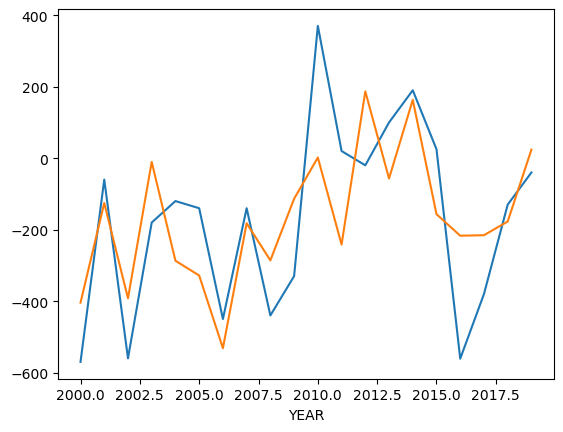

In [13]:
mbdf['in_situ_mb'] = gdir_new.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']
mbmod = massbalance.MonthlyTIModel(gdir_new, # Running the simulation with the set parameters
                                           melt_f=df['melt_f'],
                                           prcp_fac=df['prcp_fac'],
                                           temp_bias=df['temp_bias'],
                                           check_calib_params=False) 
        

mbdf['mod_mb_0'] = mbmod.get_specific_mb(fls=gdir_new.read_pickle('inversion_flowlines'), year=mbdf.index)

mbdf['in_situ_mb'] = gdir_new.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

mbdf['in_situ_mb'].plot()
mbdf['mod_mb_0'].plot()

print("The simulated mass balance is", mbdf['mod_mb_0'].mean())
print("The in-situ mass balance is", mbdf['in_situ_mb'].mean())

# The results showing the calibration of the three parameters with the rmsd minimization for the first glacier in the wgms list

This reduces the rmsd as much as possible, the mean here is a pretty decent fit. But the average mean is not matched exactly.

# Running a diagnostic to calibrate all glaciers in our directory and storing the difference in the calculated rmsd and the mean.

Firstly extract a few glaciers at level 4, since all glaciers in the wgms list would take a long time to run

In [14]:
rgi_ids = [wgms_data_list[5], wgms_data_list[117], wgms_data_list[280], wgms_data_list[60], wgms_data_list[201]]   

gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)

2025-11-21 16:12:47: oggm.workflow: init_glacier_directories from prepro level 4 on 5 glaciers.
2025-11-21 16:12:47: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 5 glaciers
2025-11-21 16:12:47: oggm.workflow: WARNING: you are trying to run an entity task on 5 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.


In [15]:
mean_differences = []
rmsds = []

for gdir in gdirs:
    df = mb_calibration_from_wgms_mb(gdir,
                                ref_mb=gdir.get_ref_mb_data().loc[1953:2019]['ANNUAL_BALANCE'], # run for all years - not all years are populated
                                overwrite_gdir=True,
                                mb_model_class=MonthlyTIModel,
                                calibrate_params= ('prcp_fac', 'melt_f', 'temp_bias'), # Changed to take in a tuple, this can allow us to change the order/number of parameters calibrated easily
                                melt_f_min=1.5,
                                melt_f_max=17.0,
                                temp_bias_min=-15.0,
                                temp_bias_max=15.0,
                                prcp_fac_min=0.1,
                                prcp_fac_max=10.0,
                                write_to_gdir=True,)
    
    mbmod = massbalance.MonthlyTIModel(gdir, # Running the simulation with the set parameters
                                           melt_f=df['melt_f'],
                                           prcp_fac=df['prcp_fac'],
                                           temp_bias=df['temp_bias'],
                                           check_calib_params=False) 
        

    rmsds.append(df['rmsd'])
    mean_differences.append(df['reference_mb'] - mbmod.get_specific_mb(fls=gdir.read_pickle('inversion_flowlines'), year=np.arange(2000, 2020)).mean())

Now looking into the minimised RMSD values, the differences in the mean mass balances and the range of differences in mean that we can see here.

The Hinteresferner glacier seemed to work relatively well with matching the mean. But we can see that depending on data avaliability that this may not always be possible.

In [16]:
print("The average rmsds are: ", np.array(rmsds).mean())
print("The average mean differences in the mean mass balances are: ", np.array(mean_differences).mean())
print("The range in the mean differences in the mean mass balances are: ", np.array(mean_differences).min(), np.array(mean_differences).max())

# Note that this last glacier has relatively sparse data and only has values avaliable for 1988-2000
# Some of the glaciers have very few years of data, which may impact the calibration quality. And some only start from thr 1990s and continue to 2016 for example.
# There is a big variation in mean values here. This could be due to the sparse data available for some glaciers. For example, the Hintereisferner has a well-filled dataset from 2000-2019.

The average rmsds are:  574.5821914534381
The average mean differences in the mean mass balances are:  197.8941448863874
The range in the mean differences in the mean mass balances are:  -23.020338217950155 706.6566074567912
